# Linear Regression


In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [8]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)

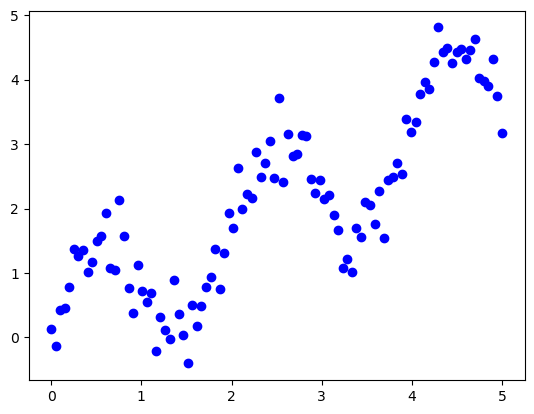

In [9]:
plt.scatter(x,y, color ='b')
plt.show()

#### nonlinear

In [10]:
regr_lin = LinearRegression()

In [11]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [12]:
regr_lin.fit(X,y)

LinearRegression()

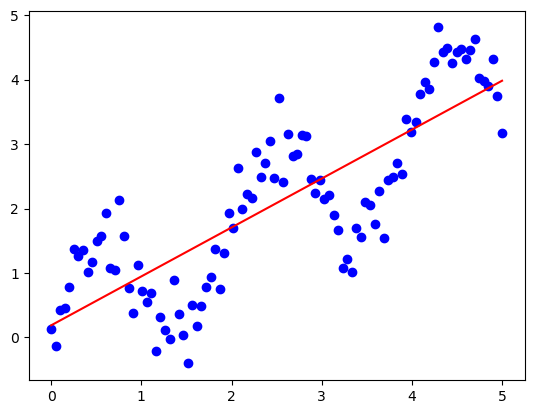

0.6336666763686789


In [13]:
Y=regr_lin.predict(X)
plt.scatter(x,y, color='b')
plt.plot(x,Y , color='r')
plt.show()
mse = np.sum((Y-y)**2) / len(y)
print(mse)

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [14]:
print(x.shape)

(100,)


In [15]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
print(X_poly.shape)

(100, 5)


In [16]:
regr_poly = LinearRegression()

In [17]:
regr_poly.fit(X_poly, y)

LinearRegression()

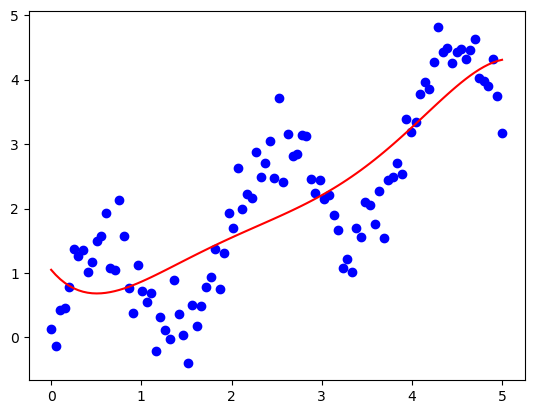

In [18]:
plt.scatter(x,y, color='b')
plt.plot(x, regr_poly.predict(X_poly), 'r')
plt.show()

In [19]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-1.67584562  2.37785763 -1.10273971  0.23322835 -0.01783465]
interception:  1.049185066148115


In [20]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b #T =轉置；列 (Row)與行 (Column)對調

array([1.04918507, 0.97047119, 0.90305671, 0.84614298, 0.79896642,
       0.76079771, 0.73094117, 0.70873401, 0.69354563, 0.68477694,
       0.68185965, 0.68425554, 0.69145579, 0.70298025, 0.71837678,
       0.73722047, 0.75911304, 0.78368203, 0.81058017, 0.83948466,
       0.87009644, 0.90213953, 0.93536029, 0.96952673, 1.00442781,
       1.03987275, 1.07569028, 1.11172799, 1.14785161, 1.18394427,
       1.21990586, 1.25565227, 1.29111474, 1.3262391 , 1.36098512,
       1.39532575, 1.42924647, 1.46274457, 1.49582843, 1.52851682,
       1.56083824, 1.59283013, 1.62453827, 1.65601599, 1.68732352,
       1.71852726, 1.74969909, 1.78091567, 1.8122577 , 1.84380929,
       1.87565717, 1.90789006, 1.94059792, 1.97387126, 2.00780046,
       2.04247502, 2.07798291, 2.1144098 , 2.15183845, 2.1903479 ,
       2.23001287, 2.27090295, 2.31308201, 2.35660741, 2.40152932,
       2.44789004, 2.49572328, 2.54505345, 2.59589497, 2.64825154,
       2.70211549, 2.75746701, 2.81427352, 2.87248889, 2.93205

In [21]:
regr_poly.predict(X_poly)

array([1.04918507, 0.97047119, 0.90305671, 0.84614298, 0.79896642,
       0.76079771, 0.73094117, 0.70873401, 0.69354563, 0.68477694,
       0.68185965, 0.68425554, 0.69145579, 0.70298025, 0.71837678,
       0.73722047, 0.75911304, 0.78368203, 0.81058017, 0.83948466,
       0.87009644, 0.90213953, 0.93536029, 0.96952673, 1.00442781,
       1.03987275, 1.07569028, 1.11172799, 1.14785161, 1.18394427,
       1.21990586, 1.25565227, 1.29111474, 1.3262391 , 1.36098512,
       1.39532575, 1.42924647, 1.46274457, 1.49582843, 1.52851682,
       1.56083824, 1.59283013, 1.62453827, 1.65601599, 1.68732352,
       1.71852726, 1.74969909, 1.78091567, 1.8122577 , 1.84380929,
       1.87565717, 1.90789006, 1.94059792, 1.97387126, 2.00780046,
       2.04247502, 2.07798291, 2.1144098 , 2.15183845, 2.1903479 ,
       2.23001287, 2.27090295, 2.31308201, 2.35660741, 2.40152932,
       2.44789004, 2.49572328, 2.54505345, 2.59589497, 2.64825154,
       2.70211549, 2.75746701, 2.81427352, 2.87248889, 2.93205

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [22]:
# normal distrubution
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [23]:
sigma = 0.3

In [24]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])



In [25]:
regr_rbf = LinearRegression()

In [26]:
regr_rbf.fit(X_rbf, y)

LinearRegression()

In [27]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')

In [28]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.77255899 -1.78144193  1.27647833  0.0510745   3.25007239]
interception:  1.7985577319970045


#### Comparison

In [29]:
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

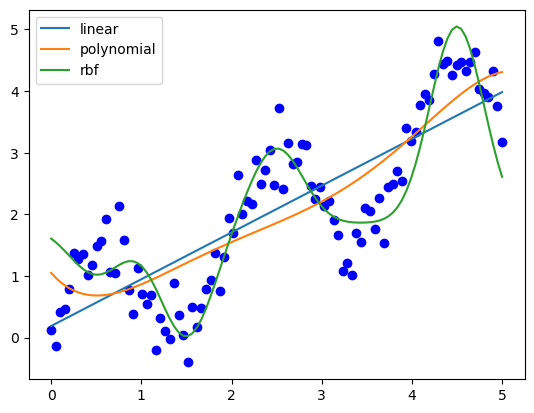

In [31]:
plt.scatter(x,y, color='b')

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()
plt.show()

## 請計算模型的MSE

In [32]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.6336666763686789


In [33]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.5723724682029492


In [34]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.2767653935458674
